# Compositional Benchmarks: Subset-Level Analysis

This notebook generates figures and tables for **subset-level** performance on compositional benchmarks.

## Visualizations:
1. **Heatmap**: Models × Subsets with color-coded accuracy
2. **Grouped Bar Plot**: Per-dataset subset breakdown with model comparison
3. **Delta Heatmap**: Improvement over CLIP per subset
4. **LaTeX Tables**: Per-subset accuracy tables for paper

In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
# =============================================================================
# SETUP: Load data using evalviz pipeline (same as comp_benchmarks_figures.ipynb)
# =============================================================================

import sys
from pathlib import Path

# Add parent directory (experiments/) to path for evalviz imports
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from evalviz.config import load_runs_from_files, load_methods, load_benchmarks
from evalviz.io import load_results_from_runs
from evalviz.preprocess import apply_mappings, add_dataset_type_columns, apply_dataset_merge_rules
from evalviz.enrich import attach_method_metadata, attach_benchmark_metadata
from evalviz.capabilities import (
    annotate_capabilities_hierarchical,
    get_capability_ordering,
)
from evalviz.benchmarks import build_subset_capability_lookup
from evalviz.tables import build_compositional_tables_for_dataset, build_all_compositional_tables

import tueplots
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes

# =============================================================================
# LOAD DATA
# =============================================================================

ours = "../configs/runs_ours_final.json"

runs = load_runs_from_files(
    "../configs/runs_baselines.json",
    "../configs/runs_external.json",
    ours
)

methods = load_methods("../configs/methods.json")
bench_cfg = load_benchmarks("../configs/benchmarks.json")

df = load_results_from_runs(runs)
df = apply_dataset_merge_rules(df, bench_cfg)
df = apply_mappings(df, bench_cfg)
df = add_dataset_type_columns(df)
df = attach_method_metadata(df, methods)
df = attach_benchmark_metadata(df, bench_cfg)

# Build capability lookup and annotate
subset_cap_lookup = build_subset_capability_lookup(bench_cfg)
df = annotate_capabilities_hierarchical(df, subset_cap_lookup, bench_cfg)

# Get canonical ordering
TOP_CAPS, SUB_CAPS = get_capability_ordering(bench_cfg)

print(f"Loaded {len(df)} rows")
print(f"Top-level capabilities: {TOP_CAPS}")
print(f"Datasets: {df['dataset'].unique().tolist()}")

Loaded 10517 rows
Top-level capabilities: ['EntityContent', 'RelationalStructure', 'Binding', 'Linguistic']
Datasets: ['VL_CheckList', 'ARO', 'ColorFoil', 'SPEC', 'COLA', 'VisMin', 'CLIPBench', 'Winoground', 'NegBench', 'BLA', 'ControlledImages', 'COCO-CF', 'SugarCrepe', 'VALSE', 'ColorSwap', 'SugarCrepe++', 'MMVP']


In [29]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Output directory
FIGURES_DIR = Path("../paper_figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Colorblind-friendly palette (Paul Tol's bright)
COLORBLIND_PALETTE = [f"#{c}" if not str(c).startswith("#") else str(c) for c in palettes.paultol_bright]

# Our model - use distinctive dark blue/purple color (NOT red)
OUR_MODEL = "CS-CLIP"
OUR_MODEL_COLOR = "#1F77B4"  # Distinctive blue - stands out clearly

# Model styling (consistent with comp_benchmarks_figures.ipynb)
MODEL_STYLES = {
    "CLIP": {"color": "#777777", "marker": "o"},
    "NegCLIP (COCO)": {"color": COLORBLIND_PALETTE[1], "marker": "o"},
    "CS-CLIP": {"color": OUR_MODEL_COLOR, "marker": "*"},  # Our model - distinctive blue
    "CE-CLIP": {"color": COLORBLIND_PALETTE[5], "marker": "P"},  # Added CE-CLIP
    "FSC CLIP (COCO)": {"color": COLORBLIND_PALETTE[0], "marker": "s"},
    "READCLIP": {"color": COLORBLIND_PALETTE[3], "marker": "^"},
    "DeGLA": {"color": COLORBLIND_PALETTE[4], "marker": "D"},
    "SigLIP": {"color": COLORBLIND_PALETTE[6], "marker": "v"},
    "SigLIP2": {"color": "#8B4513", "marker": "p"},
}

# Models to show in figures (added CE-CLIP)
SHOW_MODELS = ["CLIP", "NegCLIP (COCO)", "CE-CLIP", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]
BASELINE_LABEL = "CLIP"

# =============================================================================
# NAME MAPPINGS - for cleaner display
# =============================================================================

# Dataset display names
DATASET_DISPLAY_NAMES = {
    "VG_Attribution": "VGA",
    "VG_Relation": "VGR",
    "SugarCrepe++": "SC++",
    "SugarCrepe": "SC",
    "VL_CheckList": "VLC",
    "Flickr30k_Order": "F30k_Ord",
    "COCO_Order": "COCO_Ord",
    "ControlledImages": "WhatsUp",
    "NegBench": "NegBench",
    # Add more as needed
}

# Subset display names (for long subset names)
SUBSET_DISPLAY_NAMES = {
    # NegBench subsets - use short names
    "msr_vtt_mcq_rephrased_llama": "MSRVTT",
    "VOC2007_mcq_llama3.1_rephrased": "VOC2007",
    "COCO_val_mcq_llama3.1_rephrased": "COCO",
    # Other subsets
    "attribute_wrong": "attr_wrong",
    "object_wrong": "obj_wrong", 
    "subject_wrong": "subj_wrong",
    # Add more as needed
}

def get_display_name(name, name_map):
    """Get display name from mapping, return original if not found."""
    return name_map.get(name, name)

def get_dataset_display(dataset):
    """Get short display name for dataset."""
    return DATASET_DISPLAY_NAMES.get(dataset, dataset)

def get_subset_display(subset):
    """Get short display name for subset."""
    return SUBSET_DISPLAY_NAMES.get(subset, subset)

def get_dataset_subsets(subset_table):
    """Extract dataset -> [subsets] mapping from row names (index)."""
    datasets = {}
    for idx in subset_table.index:
        parts = idx.split("/")
        if len(parts) == 2:
            dataset, subset = parts
            if dataset not in datasets:
                datasets[dataset] = []
            datasets[dataset].append(subset)
    return datasets

# ICML style
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

print(f"Output directory: {FIGURES_DIR}")
print(f"Models to show: {SHOW_MODELS}")

Output directory: ../paper_figures
Models to show: ['CLIP', 'NegCLIP (COCO)', 'CE-CLIP', 'CS-CLIP', 'FSC CLIP (COCO)', 'READCLIP', 'DeGLA']


In [30]:
# =============================================================================
# BUILD SUBSET-LEVEL TABLES
# =============================================================================

def build_subset_table(df, metric="text_contrastive_accuracy"):
    """
    Build a table with rows=dataset/subset, cols=models.
    Returns both absolute values and delta vs baseline.
    """
    # Filter to compositional benchmarks with the specified metric
    comp_df = df[(df["benchmark_type"] == "compositional") & (df["metric"] == metric)].copy()
    
    # DEBUG: Check if NegBench exists in the full dataframe
    negbench_df = df[df["dataset"] == "NegBench"]
    if len(negbench_df) > 0:
        print(f"DEBUG: Found {len(negbench_df)} NegBench rows in full df")
        print(f"  benchmark_type: {negbench_df['benchmark_type'].unique()}")
        print(f"  metric: {negbench_df['metric'].unique()}")
        print(f"  subsets: {negbench_df['subset'].unique()}")
        
        # Include NegBench even if not marked as compositional
        negbench_metric = negbench_df[negbench_df["metric"] == metric]
        if len(negbench_metric) > 0:
            print(f"  Adding {len(negbench_metric)} NegBench rows to compositional data")
            comp_df = pd.concat([comp_df, negbench_metric], ignore_index=True)
    else:
        print("DEBUG: NegBench not found in dataframe")
        print(f"  Available datasets: {df['dataset'].unique().tolist()}")
    
    if comp_df.empty:
        print(f"No data found for metric: {metric}")
        return pd.DataFrame(), pd.DataFrame()
    
    # Average duplicates (seeds)
    grouped = comp_df.groupby(["run_label", "dataset", "subset"], as_index=False)["value"].mean()
    
    # Create combined column name: dataset/subset
    grouped["dataset_subset"] = grouped["dataset"] + "/" + grouped["subset"]
    
    # Pivot to subsets × models (rows=subsets, cols=models)
    pivot = grouped.pivot_table(
        index="dataset_subset",
        columns="run_label",
        values="value"
    )
    
    # Sort rows by dataset then subset
    pivot = pivot.reindex(sorted(pivot.index), axis=0)
    
    return pivot


# Build the subset table
subset_table = build_subset_table(df, metric="text_contrastive_accuracy")

print(f"Subset table shape: {subset_table.shape}")
print(f"Subsets (rows): {list(subset_table.index[:10])}...")
print(f"Models (cols): {list(subset_table.columns)}")

# Debug: Show all available datasets and subsets
print("\n=== Available datasets and subsets ===")
datasets_found = get_dataset_subsets(subset_table) if len(subset_table) > 0 else {}
for ds, subs in datasets_found.items():
    print(f"  {ds}: {subs}")

# Filter to show only selected models
subset_table_filtered = subset_table[[m for m in SHOW_MODELS if m in subset_table.columns]]
print(f"\nFiltered to {len(subset_table_filtered.columns)} models")

DEBUG: Found 114 NegBench rows in full df
  benchmark_type: ['compositional']
  metric: ['accuracy' 'text_contrastive_accuracy']
  subsets: ['COCO_val_mcq_llama3.1_rephrased' 'msr_vtt_mcq_rephrased_llama'
 'VOC2007_mcq_llama3.1_rephrased']
  Adding 57 NegBench rows to compositional data
Subset table shape: (69, 19)
Subsets (rows): ['ARO/COCO_Order', 'ARO/Flickr30k_Order', 'ARO/VG_Attribution', 'ARO/VG_Relation', 'BLA/ap', 'BLA/co', 'BLA/rc', 'COCO-CF/all', 'COLA/multi_objects', 'ColorFoil/all']...
Models (cols): ['CE CLIP', 'CLIC CogVLM (LAION)', 'CLIC CogVLM (PixPR RedCaps)', 'CLIP', 'CLoVe', 'CON CLIP', 'CS-CLIP', 'DAC (LLM)', 'DAC (SAM)', 'DeGLA', 'FSC CLIP (CC3M)', 'FSC CLIP (COCO)', 'FSC CLIP (LAION+COCO)', 'LaCLIP (CC12M)', 'LabCLIP', 'NegCLIP (COCO)', 'READCLIP', 'TSVLC', 'TripletCLIP (CC12M)']

=== Available datasets and subsets ===
  ARO: ['COCO_Order', 'Flickr30k_Order', 'VG_Attribution', 'VG_Relation']
  BLA: ['ap', 'co', 'rc']
  COCO-CF: ['all']
  COLA: ['multi_objects']
  

In [31]:
# =============================================================================
# COMPUTE DELTA VS CLIP
# =============================================================================

if BASELINE_LABEL in subset_table.columns:
    clip_baseline = subset_table[BASELINE_LABEL]
    delta_table = (subset_table.subtract(clip_baseline, axis=0)) * 100  # Convert to percentage points
    delta_table = delta_table.drop(columns=BASELINE_LABEL, errors="ignore")
    
    # Filter to show models
    delta_filtered = delta_table[[m for m in SHOW_MODELS if m in delta_table.columns and m != BASELINE_LABEL]]
    
    print("Delta vs CLIP (percentage points):")
    print(f"Shape: {delta_filtered.shape}")
    
    # Show average delta per model
    avg_delta = delta_filtered.mean(axis=0).sort_values(ascending=False)
    print("\nAverage Δ vs CLIP:")
    for model, delta in avg_delta.items():
        print(f"  {model}: {delta:+.2f}%")
else:
    print(f"Baseline '{BASELINE_LABEL}' not found in data")
    delta_filtered = pd.DataFrame()

Delta vs CLIP (percentage points):
Shape: (69, 5)

Average Δ vs CLIP:
  CS-CLIP: +6.78%
  READCLIP: +6.51%
  FSC CLIP (COCO): +6.22%
  DeGLA: +5.58%
  NegCLIP (COCO): +4.52%


## Figure 1: Heatmap - All Subsets × Models (Δ vs CLIP)

Shows improvement over CLIP for each model on each subset, color-coded from regression (red) to improvement (blue).

Splitting 16 datasets into two figures:
  Part 1 (10): ['ARO', 'BLA', 'COCO-CF', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'MMVP', 'NegBench', 'SugarCrepe++']
  Part 2 (6): ['SPEC', 'SugarCrepe', 'VALSE', 'VL_CheckList', 'VisMin', 'Winoground']
  Part 1: 34 subsets
  Part 2: 35 subsets

--- Figure 1: 34 subsets from 10 datasets ---
✓ Saved: ../paper_figures/subset_heatmap_acc_delta_colored_part1.pdf


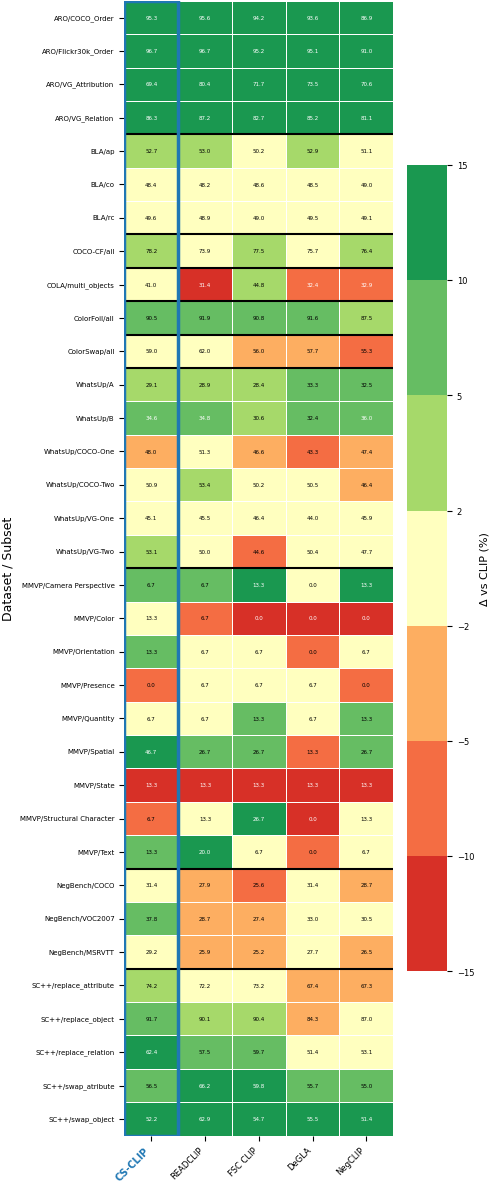


--- Figure 2: 35 subsets from 6 datasets ---
✓ Saved: ../paper_figures/subset_heatmap_acc_delta_colored_part2.pdf


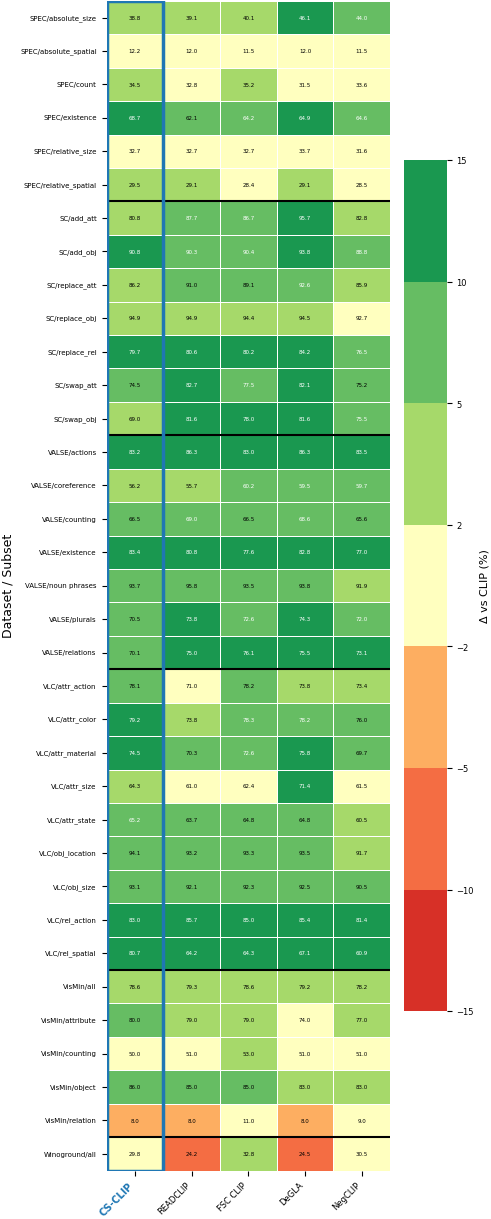

In [39]:
# =============================================================================
# FIGURE 1: HEATMAP - All Subsets × Models (Delta vs CLIP)
# =============================================================================

from matplotlib.colors import ListedColormap, BoundaryNorm

def create_discrete_diverging_cmap(n_bins=7):
    """
    Create a discrete Red-White-Green colormap for delta heatmaps.
    Red = regression (negative), White = neutral (near 0), Green = improvement (positive)
    """
    # Define colors: dark red -> light red -> white -> light green -> dark green
    colors = [
        "#d73027",  # dark red (large regression)
        "#f46d43",  # orange-red
        "#fdae61",  # light orange
        "#ffffbf",  # pale yellow (neutral)
        "#a6d96a",  # light green
        "#66bd63",  # medium green
        "#1a9850",  # dark green (large improvement)
    ]
    return ListedColormap(colors)


def plot_subset_heatmap_acc_colored_by_delta(acc_table, delta_table, title="Accuracy (colored by Δ vs CLIP)", 
                                              figsize=(14, 6), vmin=-15, vmax=15, save_path=None,
                                              use_short_names=True, discrete=True, n_bins=7,
                                              sort_by_avg=True):
    """
    Plot heatmap with rows=subsets, cols=models.
    SHOWS absolute accuracy values as annotations.
    COLORS cells based on delta vs baseline (Green = improvement, Red = regression).
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    
    # Sort columns by average delta improvement (descending)
    if sort_by_avg:
        avg_delta = delta_table.mean(axis=0).sort_values(ascending=False)
        sorted_cols = avg_delta.index.tolist()
        delta_data = delta_table[sorted_cols]
        acc_data = acc_table[sorted_cols] * 100
    else:
        delta_data = delta_table
        acc_data = acc_table * 100
    
    # Shortened model names for x-axis
    model_labels = []
    for m in delta_data.columns:
        short_name = m.replace(" (COCO)", "").replace(" (CC3M)", "")
        model_labels.append(short_name)
    
    # Shorten row labels (dataset/subset)
    if use_short_names:
        row_labels = []
        for idx in delta_data.index:
            parts = idx.split("/")
            if len(parts) == 2:
                ds = get_dataset_display(parts[0])
                sub = get_subset_display(parts[1])
                row_labels.append(f"{ds}/{sub}")
            else:
                row_labels.append(idx)
    else:
        row_labels = list(delta_data.index)
    
    # Create discrete colormap and boundaries
    if discrete:
        cmap = create_discrete_diverging_cmap(n_bins)
        boundaries = [-15, -10, -5, -2, 2, 5, 10, 15]
        norm = BoundaryNorm(boundaries, cmap.N, clip=True)
        
        # Create heatmap colored by delta, but we'll add custom annotations
        im = sns.heatmap(
            delta_data,
            ax=ax,
            cmap=cmap,
            norm=norm,
            annot=False,  # We'll add custom annotations
            cbar_kws={"label": "Δ vs CLIP (%)", "shrink": 0.8, "ticks": boundaries},
            linewidths=0.5,
            linecolor="white",
            xticklabels=model_labels,
            yticklabels=row_labels
        )
        
        # Add accuracy values as annotations (with 1 decimal place)
        for i in range(len(delta_data.index)):
            for j in range(len(delta_data.columns)):
                acc_val = acc_data.iloc[i, j]
                # Choose text color based on background
                delta_val = delta_data.iloc[i, j]
                text_color = "white" if abs(delta_val) > 8 else "black"
                ax.text(j + 0.5, i + 0.5, f"{acc_val:.1f}", 
                       ha="center", va="center", fontsize=4, color=text_color)
    else:
        # Continuous colormap
        im = sns.heatmap(
            delta_data,
            ax=ax,
            cmap="RdYlGn",
            center=0,
            vmin=vmin,
            vmax=vmax,
            annot=False,
            cbar_kws={"label": "Δ vs CLIP (%)", "shrink": 0.8},
            linewidths=0.5,
            linecolor="white",
            xticklabels=model_labels,
            yticklabels=row_labels
        )
        
        # Add accuracy values as annotations (with 1 decimal place)
        for i in range(len(delta_data.index)):
            for j in range(len(delta_data.columns)):
                acc_val = acc_data.iloc[i, j]
                delta_val = delta_data.iloc[i, j]
                text_color = "white" if abs(delta_val) > 8 else "black"
                ax.text(j + 0.5, i + 0.5, f"{acc_val:.1f}", 
                       ha="center", va="center", fontsize=4, color=text_color)
    
    ax.set_title("")  # No title
    ax.set_xlabel("")  # No x-axis label
    ax.set_ylabel("Dataset / Subset", fontsize=9)
    
    # Rotate x labels and highlight our model (CS-CLIP)
    plt.xticks(rotation=45, ha="right", fontsize=6)
    plt.yticks(fontsize=5)
    
    # Make CS-CLIP label bold and colored (using blue, not red)
    for i, label in enumerate(ax.get_xticklabels()):
        label_text = label.get_text()
        model_short = OUR_MODEL.replace(" (COCO)", "").replace(" (CC3M)", "")
        if model_short in label_text or label_text == model_short:
            label.set_fontweight("bold")
            label.set_color(OUR_MODEL_COLOR)
            label.set_fontsize(7)
    
    # Add vertical highlight for our model column (CS-CLIP) with BLUE border
    for j, col in enumerate(delta_data.columns):
        if OUR_MODEL in col or col == OUR_MODEL:
            # Draw a thick BLUE border around CS-CLIP column
            rect = plt.Rectangle((j, 0), 1, len(delta_data.index), 
                                 fill=False, edgecolor=OUR_MODEL_COLOR, 
                                 linewidth=2.5, zorder=10)
            ax.add_patch(rect)
    
    # Add horizontal lines between datasets
    prev_dataset = None
    for i, idx in enumerate(delta_data.index):
        current_dataset = idx.split("/")[0]
        if prev_dataset and current_dataset != prev_dataset:
            ax.axhline(y=i, color="black", linewidth=1.5)
        prev_dataset = current_dataset
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Plot heatmap: accuracy values colored by delta
# Split into two figures for better readability
if len(delta_filtered) > 0:
    # Get accuracy table aligned with delta table
    acc_for_plot = subset_table_filtered.loc[delta_filtered.index, delta_filtered.columns]
    
    # Sort models by OVERALL average delta (before splitting)
    overall_avg_delta = delta_filtered.mean(axis=0).sort_values(ascending=False)
    sorted_model_order = overall_avg_delta.index.tolist()
    
    # Get all datasets
    all_datasets_in_data = []
    for idx in delta_filtered.index:
        ds = idx.split("/")[0]
        if ds not in all_datasets_in_data:
            all_datasets_in_data.append(ds)
    
    # Manually specify part 2 datasets to balance subset counts
    # SPEC moved from part 1 to part 2 to balance (was 40/29, now should be ~35/34)
    part2_datasets = ['SPEC', 'SugarCrepe', 'VALSE', 'VL_CheckList', 'VisMin', 'Winoground']
    datasets_part1 = [d for d in all_datasets_in_data if d not in part2_datasets]
    datasets_part2 = [d for d in all_datasets_in_data if d in part2_datasets]
    
    print(f"Splitting {len(all_datasets_in_data)} datasets into two figures:")
    print(f"  Part 1 ({len(datasets_part1)}): {datasets_part1}")
    print(f"  Part 2 ({len(datasets_part2)}): {datasets_part2}")
    
    # Filter rows for part 1
    rows_part1 = [idx for idx in delta_filtered.index if idx.split("/")[0] in datasets_part1]
    delta_part1 = delta_filtered.loc[rows_part1, sorted_model_order]
    acc_part1 = acc_for_plot.loc[rows_part1, sorted_model_order]
    
    # Filter rows for part 2
    rows_part2 = [idx for idx in delta_filtered.index if idx.split("/")[0] in datasets_part2]
    delta_part2 = delta_filtered.loc[rows_part2, sorted_model_order]
    acc_part2 = acc_for_plot.loc[rows_part2, sorted_model_order]
    
    print(f"  Part 1: {len(rows_part1)} subsets")
    print(f"  Part 2: {len(rows_part2)} subsets")
    
    # Adjust figure heights based on number of rows
    height_part1 = max(6, len(rows_part1) * 0.35)
    height_part2 = max(6, len(rows_part2) * 0.35)
    
    # Plot Part 1 (sorting already done via column order)
    print(f"\n--- Figure 1: {len(rows_part1)} subsets from {len(datasets_part1)} datasets ---")
    fig1 = plot_subset_heatmap_acc_colored_by_delta(
        acc_part1,
        delta_part1,
        title="",  # No title
        figsize=(5, height_part1),
        vmin=-15,
        vmax=15,
        discrete=True,
        n_bins=7,
        sort_by_avg=False,  # Already sorted by overall
        save_path=FIGURES_DIR / "subset_heatmap_acc_delta_colored_part1.pdf"
    )
    
    # Plot Part 2 (sorting already done via column order)
    print(f"\n--- Figure 2: {len(rows_part2)} subsets from {len(datasets_part2)} datasets ---")
    fig2 = plot_subset_heatmap_acc_colored_by_delta(
        acc_part2,
        delta_part2,
        title="",  # No title
        figsize=(5, height_part2),
        vmin=-15,
        vmax=15,
        discrete=True,
        n_bins=7,
        sort_by_avg=False,  # Already sorted by overall
        save_path=FIGURES_DIR / "subset_heatmap_acc_delta_colored_part2.pdf"
    )

✓ Saved: ../paper_figures/subset_heatmap_delta_values_part1.pdf


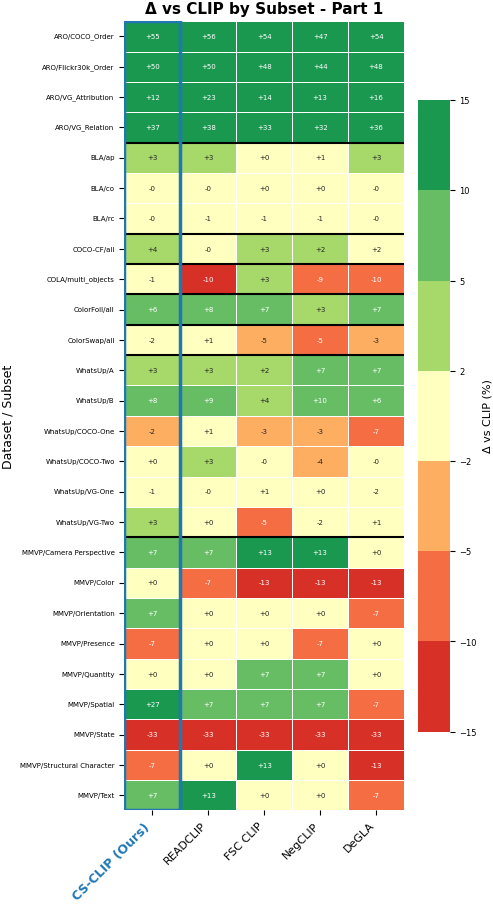

✓ Saved: ../paper_figures/subset_heatmap_delta_values_part2.pdf


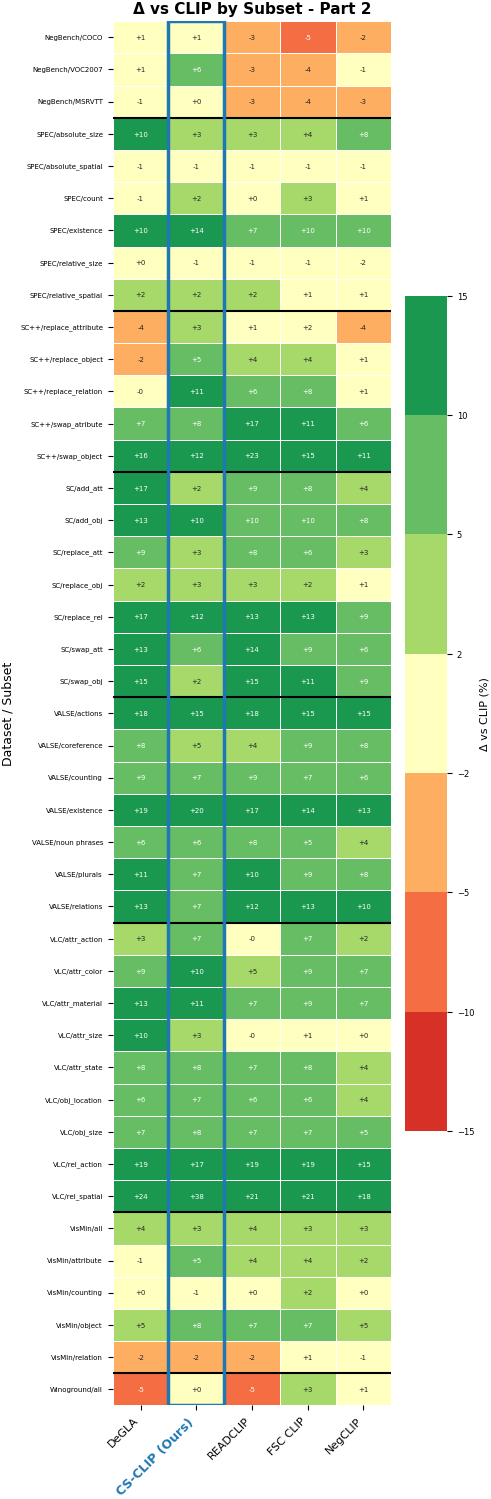

In [33]:
# =============================================================================
# FIGURE 2: DELTA HEATMAP - Pure Delta Values (for reference)
# =============================================================================

def plot_delta_heatmap(delta_table, title="Δ Accuracy vs CLIP", figsize=(14, 5),
                       vmin=-15, vmax=15, save_path=None,
                       use_short_names=True, discrete=True, n_bins=7, sort_by_avg=True):
    """
    Plot heatmap of improvement over baseline (shows delta values).
    Rows=subsets, Cols=models.
    Green = improvement, Red = regression (intuitive traffic light colors).
    Uses discrete color bins for clearer interpretation.
    Models sorted by average improvement (descending) if sort_by_avg=True.
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    
    # Sort columns by average delta (descending - best improvement first) if requested
    if sort_by_avg:
        avg_delta = delta_table.mean(axis=0).sort_values(ascending=False)
        sorted_cols = avg_delta.index.tolist()
        delta_table = delta_table[sorted_cols]
    
    # Shortened model names
    model_labels = []
    for m in delta_table.columns:
        short_name = m.replace(" (COCO)", "").replace(" (CC3M)", "")
        model_labels.append(short_name)
    
    # Shorten row labels
    if use_short_names:
        row_labels = []
        for idx in delta_table.index:
            parts = idx.split("/")
            if len(parts) == 2:
                ds = get_dataset_display(parts[0])
                sub = get_subset_display(parts[1])
                row_labels.append(f"{ds}/{sub}")
            else:
                row_labels.append(idx)
    else:
        row_labels = list(delta_table.index)
    
    # Create discrete colormap and boundaries
    if discrete:
        cmap = create_discrete_diverging_cmap(n_bins)
        boundaries = [-15, -10, -5, -2, 2, 5, 10, 15]
        norm = BoundaryNorm(boundaries, cmap.N, clip=True)
        
        sns.heatmap(
            delta_table,
            ax=ax,
            cmap=cmap,
            norm=norm,
            annot=True,
            fmt="+.0f",
            annot_kws={"size": 5},
            cbar_kws={"label": "Δ vs CLIP (%)", "shrink": 0.8, "ticks": boundaries},
            linewidths=0.5,
            linecolor="white",
            xticklabels=model_labels,
            yticklabels=row_labels
        )
    else:
        sns.heatmap(
            delta_table,
            ax=ax,
            cmap="RdYlGn",
            center=0,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt="+.0f",
            annot_kws={"size": 5},
            cbar_kws={"label": "Δ vs CLIP (%)", "shrink": 0.8},
            linewidths=0.5,
            linecolor="white",
            xticklabels=model_labels,
            yticklabels=row_labels
        )
    
    ax.set_title("")  # No title
    ax.set_xlabel("")  # Remove x-axis label
    ax.set_ylabel("Dataset / Subset", fontsize=9)
    
    # Rotate x labels and highlight our model
    plt.xticks(rotation=45, ha="right", fontsize=6)
    plt.yticks(fontsize=5)
    
    # Make CS-CLIP label bold and colored (using blue, not red)
    for i, label in enumerate(ax.get_xticklabels()):
        label_text = label.get_text()
        model_short = OUR_MODEL.replace(" (COCO)", "").replace(" (CC3M)", "")
        if model_short in label_text or label_text == model_short:
            label.set_fontweight("bold")
            label.set_color(OUR_MODEL_COLOR)
            label.set_fontsize(7)
    
    # Add vertical highlight for our model column
    for j, col in enumerate(delta_table.columns):
        if OUR_MODEL in col or col == OUR_MODEL:
            rect = plt.Rectangle((j, 0), 1, len(delta_table.index), 
                                 fill=False, edgecolor=OUR_MODEL_COLOR, 
                                 linewidth=2.5, zorder=10)
            ax.add_patch(rect)
    
    # Add horizontal lines between datasets
    prev_dataset = None
    for i, idx in enumerate(delta_table.index):
        current_dataset = idx.split("/")[0]
        if prev_dataset and current_dataset != prev_dataset:
            ax.axhline(y=i, color="black", linewidth=1.5)
        prev_dataset = current_dataset
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Plot delta heatmap (shows delta values, not accuracy) - split into two figures
if len(delta_filtered) > 0:
    # Sort models by OVERALL average delta (same as main heatmap)
    overall_avg_delta = delta_filtered.mean(axis=0).sort_values(ascending=False)
    sorted_model_order = overall_avg_delta.index.tolist()
    
    # Get all datasets
    all_datasets_in_data = []
    for idx in delta_filtered.index:
        ds = idx.split("/")[0]
        if ds not in all_datasets_in_data:
            all_datasets_in_data.append(ds)
    
    # Manually specify part 2 datasets to balance subset counts (same as main heatmap)
    part2_datasets = ['SPEC', 'SugarCrepe', 'VALSE', 'VL_CheckList', 'VisMin', 'Winoground']
    datasets_part1 = [d for d in all_datasets_in_data if d not in part2_datasets]
    datasets_part2 = [d for d in all_datasets_in_data if d in part2_datasets]
    
    # Filter rows for each part, apply sorted column order
    rows_part1 = [idx for idx in delta_filtered.index if idx.split("/")[0] in datasets_part1]
    rows_part2 = [idx for idx in delta_filtered.index if idx.split("/")[0] in datasets_part2]
    
    delta_part1 = delta_filtered.loc[rows_part1, sorted_model_order]
    delta_part2 = delta_filtered.loc[rows_part2, sorted_model_order]
    
    height_part1 = max(6, len(rows_part1) * 0.35)
    height_part2 = max(6, len(rows_part2) * 0.35)
    
    # Plot Part 1
    fig1 = plot_delta_heatmap(
        delta_part1,
        title="",  # No title
        figsize=(5, height_part1),
        vmin=-15,
        vmax=15,
        discrete=True,
        sort_by_avg=False,  # Already sorted by overall
        save_path=FIGURES_DIR / "subset_heatmap_delta_values_part1.pdf"
    )
    
    # Plot Part 2
    fig2 = plot_delta_heatmap(
        delta_part2,
        title="",  # No title
        figsize=(5, height_part2),
        vmin=-15,
        vmax=15,
        discrete=True,
        sort_by_avg=False,  # Already sorted by overall
        save_path=FIGURES_DIR / "subset_heatmap_delta_values_part2.pdf"
    )

## Figure 3: Grouped Bar Plot - Per-Dataset Subset Breakdown

Shows accuracy for each subset grouped by dataset, with bars for each model.

Datasets with subsets: ['ARO', 'BLA', 'COCO-CF', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe++', 'SugarCrepe', 'VALSE', 'VL_CheckList', 'VisMin', 'Winoground']


/tmp/ipykernel_420604/2532294593.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../paper_figures/subset_bars_sugarcrepe.pdf


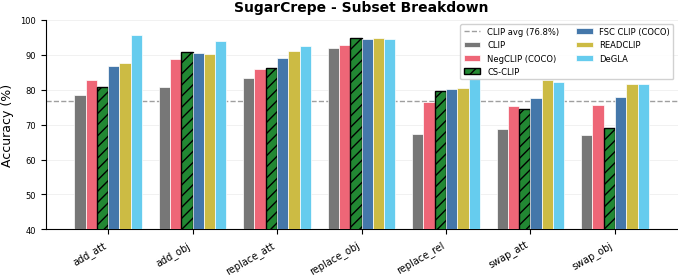

/tmp/ipykernel_420604/2532294593.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../paper_figures/subset_bars_sugarcrepeplusplus.pdf


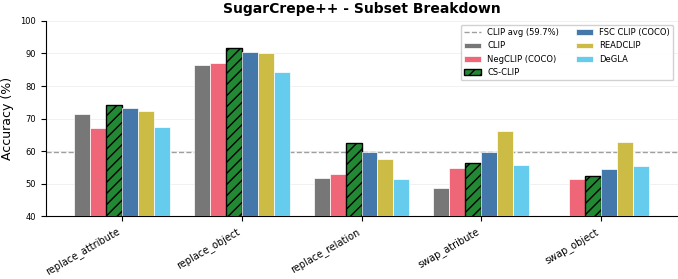

/tmp/ipykernel_420604/2532294593.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../paper_figures/subset_bars_vl_checklist.pdf


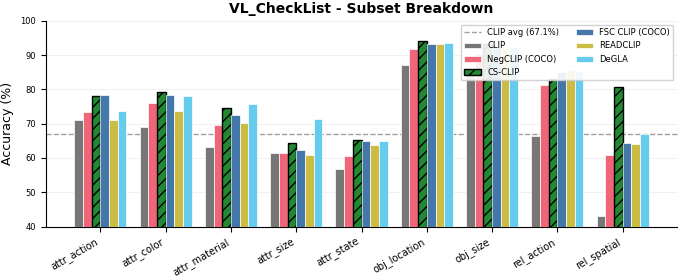

/tmp/ipykernel_420604/2532294593.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../paper_figures/subset_bars_aro.pdf


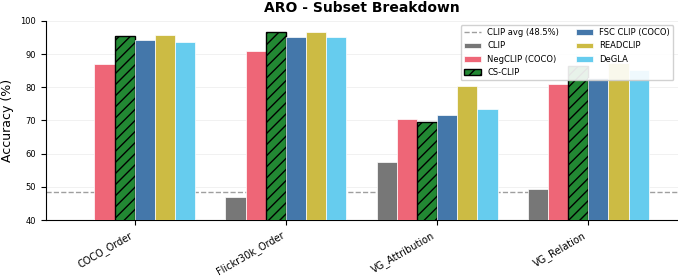

In [8]:
# =============================================================================
# FIGURE 3: GROUPED BAR PLOT - Per-Dataset Subset Breakdown
# =============================================================================

def plot_dataset_subset_bars(table, dataset_name, models, baseline_label="CLIP",
                              figsize=(6, 3), save_path=None, use_short_names=True):
    """
    Plot grouped bar chart for a single dataset showing all subsets.
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    # Get subsets for this dataset
    subsets = [idx.split("/")[1] for idx in table.index if idx.startswith(f"{dataset_name}/")]
    if not subsets:
        print(f"No subsets found for {dataset_name}")
        return None
    
    # Get data for this dataset
    rows = [f"{dataset_name}/{s}" for s in subsets]
    models_exist = [m for m in models if m in table.columns]
    data = table.loc[rows, models_exist] * 100
    
    # Get display names for subsets
    if use_short_names:
        subset_labels = [get_subset_display(s) for s in subsets]
    else:
        subset_labels = subsets
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(subsets))
    n_models = len(models_exist)
    width = 0.8 / n_models
    
    for i, model in enumerate(models_exist):
        offset = (i - n_models/2 + 0.5) * width
        color = MODEL_STYLES.get(model, {}).get("color", COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)])
        
        # Highlight CS-CLIP
        edgecolor = "black" if model == "CS-CLIP" else "white"
        linewidth = 1.0 if model == "CS-CLIP" else 0.5
        hatch = "///" if model == "CS-CLIP" else None
        
        values = data[model].values
        bars = ax.bar(x + offset, values, width, label=model, color=color,
                     edgecolor=edgecolor, linewidth=linewidth, hatch=hatch, zorder=3)
    
    # CLIP baseline line
    if baseline_label in models_exist:
        clip_avg = data[baseline_label].mean()
        ax.axhline(y=clip_avg, color="#777777", linestyle="--", linewidth=1, alpha=0.7,
                   label=f"CLIP avg ({clip_avg:.1f}%)")
    
    ax.set_xticks(x)
    ax.set_xticklabels(subset_labels, fontsize=7, rotation=30, ha="right")
    ax.set_ylabel("Accuracy (%)", fontsize=9)
    
    # Use display name for title
    title_name = get_dataset_display(dataset_name)
    ax.set_title(f"{title_name} - Subset Breakdown", fontsize=10, fontweight="bold")
    
    ax.legend(loc="upper right", fontsize=6, framealpha=0.9, ncol=2)
    ax.set_ylim(40, 100)
    
    # Style
    ax.set_facecolor("white")
    ax.grid(True, axis="y", alpha=0.3, linestyle="-", linewidth=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Plot for each major dataset
datasets = get_dataset_subsets(subset_table)
print(f"Datasets with subsets: {list(datasets.keys())}")

for dataset in ["SugarCrepe", "SugarCrepe++", "VL_CheckList", "ARO", "NegBench"]:
    if dataset in datasets:
        plot_dataset_subset_bars(
            subset_table,
            dataset,
            SHOW_MODELS,
            figsize=(7, 3),
            save_path=FIGURES_DIR / f"subset_bars_{dataset.lower().replace('+', 'plus')}.pdf"
        )
    else:
        print(f"⚠ Dataset '{dataset}' not found in data")

/tmp/ipykernel_420604/3842610482.py:66: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../paper_figures/subset_bars_all_datasets.pdf


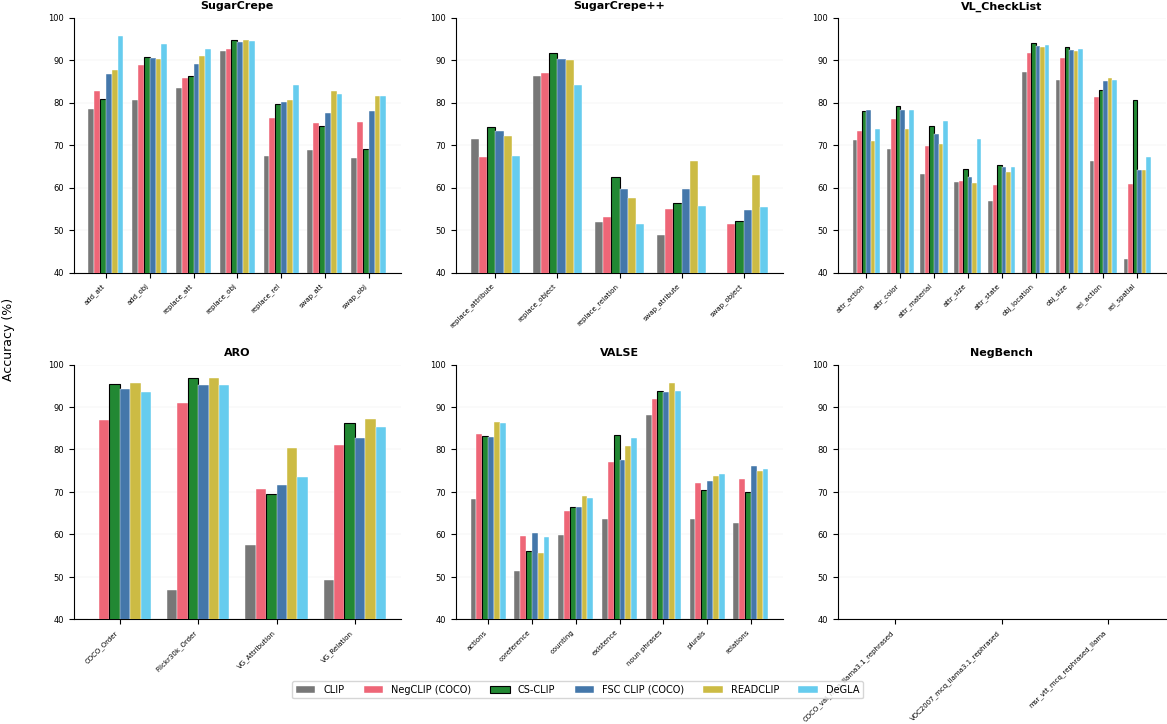

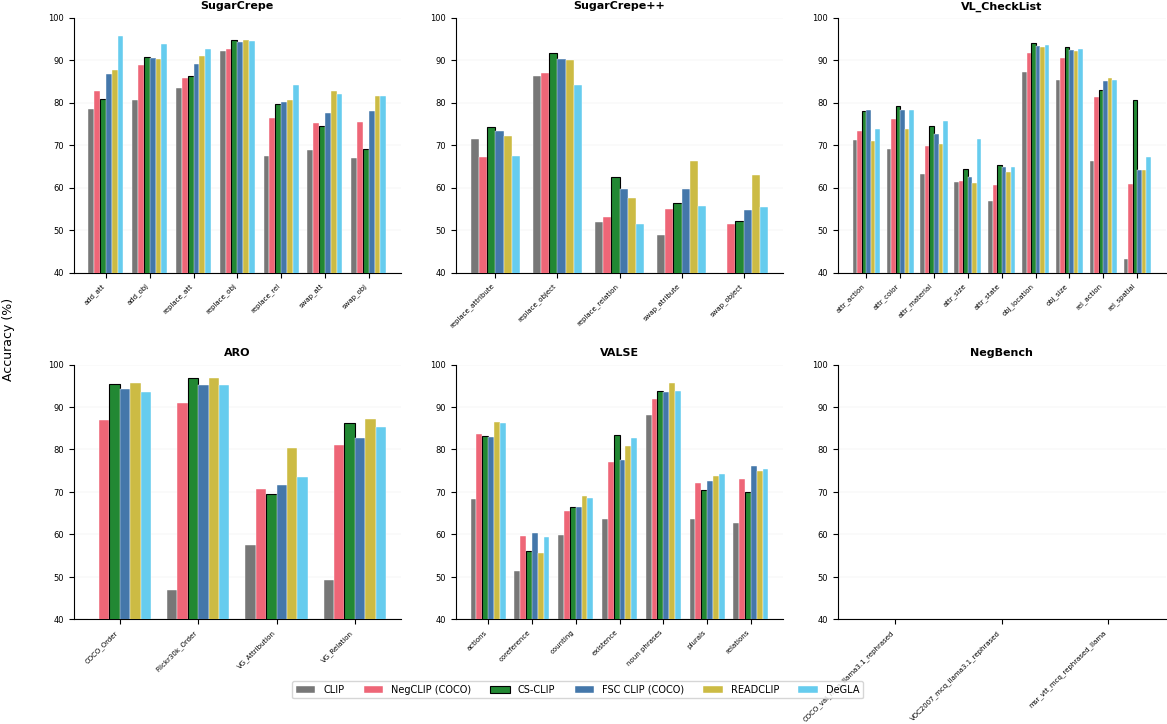

In [9]:
# =============================================================================
# FIGURE 4: MULTI-DATASET SUBPLOT - All Datasets in One Figure
# =============================================================================

def plot_all_datasets_subplots(table, models, datasets_to_show=None, ncols=2, 
                                figsize=(10, 8), save_path=None, use_short_names=True):
    """
    Create a multi-panel figure with one subplot per dataset.
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    all_datasets = get_dataset_subsets(table)
    if datasets_to_show is None:
        datasets_to_show = list(all_datasets.keys())
    
    # Filter to datasets that exist
    datasets_to_show = [d for d in datasets_to_show if d in all_datasets]
    
    if len(datasets_to_show) == 0:
        print("No datasets to show!")
        return None
    
    nrows = int(np.ceil(len(datasets_to_show) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten() if len(datasets_to_show) > 1 else [axes]
    
    models_exist = [m for m in models if m in table.columns]
    
    for idx, (ax, dataset) in enumerate(zip(axes, datasets_to_show)):
        subsets = all_datasets[dataset]
        rows = [f"{dataset}/{s}" for s in subsets]
        data = table.loc[rows, models_exist] * 100
        
        # Get display names
        if use_short_names:
            subset_labels = [get_subset_display(s) for s in subsets]
        else:
            subset_labels = subsets
        
        x = np.arange(len(subsets))
        n_models = len(models_exist)
        width = 0.8 / n_models
        
        for i, model in enumerate(models_exist):
            offset = (i - n_models/2 + 0.5) * width
            color = MODEL_STYLES.get(model, {}).get("color", COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)])
            
            edgecolor = "black" if model == "CS-CLIP" else "white"
            linewidth = 0.8 if model == "CS-CLIP" else 0.3
            
            values = data[model].values
            ax.bar(x + offset, values, width, label=model if idx == 0 else "", 
                   color=color, edgecolor=edgecolor, linewidth=linewidth, zorder=3)
        
        ax.set_xticks(x)
        ax.set_xticklabels(subset_labels, fontsize=5, rotation=45, ha="right")
        
        # Use display name for title
        title_name = get_dataset_display(dataset)
        ax.set_title(title_name, fontsize=8, fontweight="bold")
        ax.set_ylim(40, 100)
        ax.tick_params(axis="y", labelsize=6)
        
        ax.set_facecolor("white")
        ax.grid(True, axis="y", alpha=0.3, linestyle="-", linewidth=0.3, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    
    # Hide unused axes
    for ax in axes[len(datasets_to_show):]:
        ax.set_visible(False)
    
    # Single legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(models_exist), fontsize=7,
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    
    # Common y-label
    fig.text(0.02, 0.5, "Accuracy (%)", va="center", rotation="vertical", fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1, left=0.08)
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Plot all datasets (use None to auto-detect all available)
all_available_datasets = list(get_dataset_subsets(subset_table).keys())
print(f"All available datasets: {all_available_datasets}")

# Plot subset of important datasets
important_datasets = ["SugarCrepe", "SugarCrepe++", "VL_CheckList", "ARO", "VALSE", "NegBench"]
plot_all_datasets_subplots(
    subset_table,
    SHOW_MODELS,
    datasets_to_show=important_datasets,
    ncols=3,
    figsize=(12, 7),
    save_path=FIGURES_DIR / "subset_bars_all_datasets.pdf"
)

## LaTeX Tables: Per-Dataset Subset Breakdown

In [10]:
# =============================================================================
# LATEX TABLES: Per-Dataset Subset Accuracy
# =============================================================================

def generate_subset_latex_table(table, dataset, models, baseline_label="CLIP",
                                  decimals=1, highlight_best=True):
    """
    Generate LaTeX table for a specific dataset's subsets.
    Table format: rows=subsets, columns=models (transposed view for latex)
    """
    datasets = get_dataset_subsets(table)
    if dataset not in datasets:
        return f"% No data for {dataset}\n"
    
    subsets = datasets[dataset]
    rows = [f"{dataset}/{s}" for s in subsets]
    
    # Filter to models that exist (models are columns)
    models_exist = [m for m in models if m in table.columns]
    data = table.loc[rows, models_exist] * 100
    
    # Find best per row (best model per subset)
    best_per_row = {row: data.loc[row].idxmax() for row in rows}
    
    def fmt(val, model, row):
        s = f"{val:.{decimals}f}"
        if highlight_best and model == best_per_row[row]:
            s = f"\\textbf{{{s}}}"
        if model == baseline_label:
            s = f"\\underline{{{s}}}"
        if model == "CS-CLIP":
            s = f"\\emph{{{s}}}"
        return s
    
    # Escape subset names
    def escape(s):
        return s.replace("_", r"\_").replace("+", r"+")
    
    lines = []
    lines.append(r"\begin{tabular}{l" + "c" * len(models_exist) + "c}")
    lines.append(r"\toprule")
    
    # Header: Model names as columns
    header = ["Subset"] + [escape(m) for m in models_exist] + ["Avg"]
    lines.append(" & ".join(header) + r" \\")
    lines.append(r"\midrule")
    
    # Data rows (one row per subset)
    for row, subset in zip(rows, subsets):
        row_data = [escape(subset)]
        for model in models_exist:
            row_data.append(fmt(data.loc[row, model], model, row))
        # Average across models for this subset
        avg = data.loc[row].mean()
        avg_s = f"{avg:.{decimals}f}"
        row_data.append(avg_s)
        lines.append(" & ".join(row_data) + r" \\")
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    
    return "\n".join(lines)


# Generate tables for key datasets
print("="*80)
print("LATEX TABLES: Per-Subset Accuracy")
print("="*80)

for dataset in ["SugarCrepe", "SugarCrepe++", "VL_CheckList", "ARO"]:
    latex = generate_subset_latex_table(subset_table, dataset, SHOW_MODELS)
    print(f"\n% {dataset}")
    print(latex)
    
    # Save to file
    save_path = FIGURES_DIR / f"subset_table_{dataset.lower().replace('+', 'plus')}.tex"
    with open(save_path, "w") as f:
        f.write(f"% {dataset} subset accuracy\n")
        f.write(latex)
    print(f"✓ Saved: {save_path}")

LATEX TABLES: Per-Subset Accuracy

% SugarCrepe
\begin{tabular}{lcccccccc}
\toprule
Model & add\_att & add\_obj & replace\_att & replace\_obj & replace\_rel & swap\_att & swap\_obj & Avg \\
\midrule
CLIP & \underline{78.5} & \underline{80.6} & \underline{83.4} & \underline{92.1} & \underline{67.4} & \underline{68.8} & \underline{66.9} & 76.8 \\
NegCLIP (COCO) & 82.8 & 88.8 & 85.9 & 92.7 & 76.5 & 75.2 & 75.5 & 82.5 \\
CS-CLIP & \emph{80.8} & \emph{90.8} & \emph{86.2} & \emph{\textbf{94.9}} & \emph{79.7} & \emph{74.5} & \emph{69.0} & \emph{82.2} \\
FSC CLIP (COCO) & 86.7 & 90.4 & 89.1 & 94.4 & 80.2 & 77.5 & 78.0 & 85.2 \\
READCLIP & 87.7 & 90.3 & 91.0 & 94.9 & 80.6 & \textbf{82.7} & \textbf{81.6} & 87.0 \\
DeGLA & \textbf{95.7} & \textbf{93.8} & \textbf{92.6} & 94.5 & \textbf{84.2} & 82.1 & 81.6 & 89.2 \\
\bottomrule
\end{tabular}
✓ Saved: ../paper_figures/subset_table_sugarcrepe.tex

% SugarCrepe++
\begin{tabular}{lcccccc}
\toprule
Model & replace\_attribute & replace\_object & replace\

In [11]:
# =============================================================================
# SUMMARY: Per-Subset Delta Statistics
# =============================================================================

if len(delta_filtered) > 0:
    print("="*80)
    print("SUMMARY: Best/Worst Subsets for CS-CLIP")
    print("="*80)
    
    if "CS-CLIP" in delta_filtered.columns:
        csclip_delta = delta_filtered["CS-CLIP"].sort_values(ascending=False)
        
        print("\n📈 TOP 10 IMPROVEMENTS (CS-CLIP vs CLIP):")
        for subset, delta in csclip_delta.head(10).items():
            print(f"  {subset}: {delta:+.2f}%")
        
        print("\n📉 TOP 10 REGRESSIONS (CS-CLIP vs CLIP):")
        for subset, delta in csclip_delta.tail(10).items():
            print(f"  {subset}: {delta:+.2f}%")
        
        print(f"\n📊 OVERALL: {csclip_delta.mean():+.2f}% average improvement")
        print(f"   Improved on {(csclip_delta > 0).sum()} / {len(csclip_delta)} subsets")

SUMMARY: Best/Worst Subsets for CS-CLIP

📈 TOP 10 IMPROVEMENTS (CS-CLIP vs CLIP):
  ARO/COCO_Order: +55.35%
  ARO/Flickr30k_Order: +49.78%
  VL_CheckList/rel_spatial: +37.50%
  ARO/VG_Relation: +36.96%
  MMVP/Spatial: +26.67%
  VALSE/existence: +19.80%
  VL_CheckList/rel_action: +16.69%
  VALSE/actions: +14.78%
  SPEC/existence: +14.10%
  SugarCrepe/replace_rel: +12.30%

📉 TOP 10 REGRESSIONS (CS-CLIP vs CLIP):
  SPEC/absolute_spatial: -0.71%
  SPEC/relative_size: -0.87%
  COLA/multi_objects: -0.95%
  VisMin/counting: -1.00%
  ColorSwap/all: -1.67%
  VisMin/relation: -2.00%
  ControlledImages/COCO-One: -2.05%
  MMVP/Presence: -6.67%
  MMVP/Structural Character: -6.67%
  MMVP/State: -33.33%

📊 OVERALL: +6.78% average improvement
   Improved on 52 / 69 subsets


/mnt/lustre/work/oh/owl336/.conda/py-311-pytorch/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/mnt/lustre/work/oh/owl336/.conda/py-311-pytorch/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


✓ Saved: ../paper_figures/subset_heatmap_compact.pdf


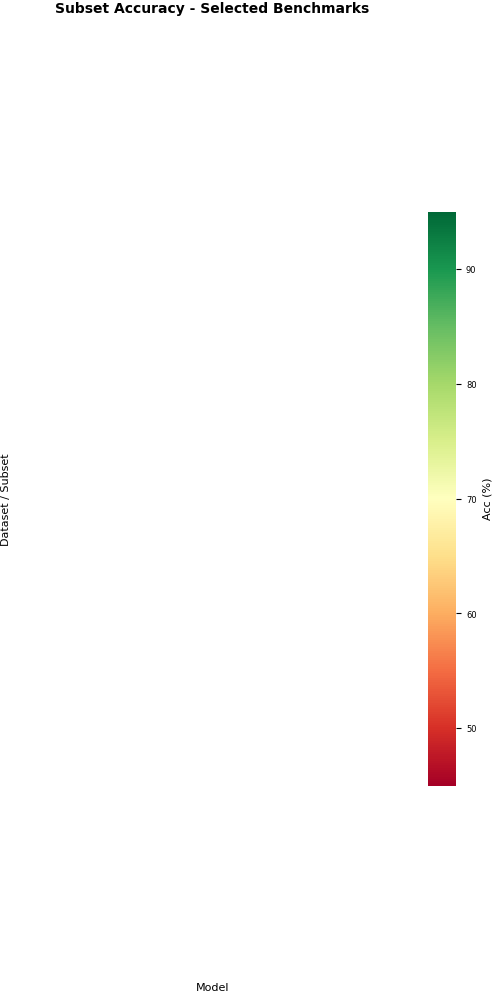

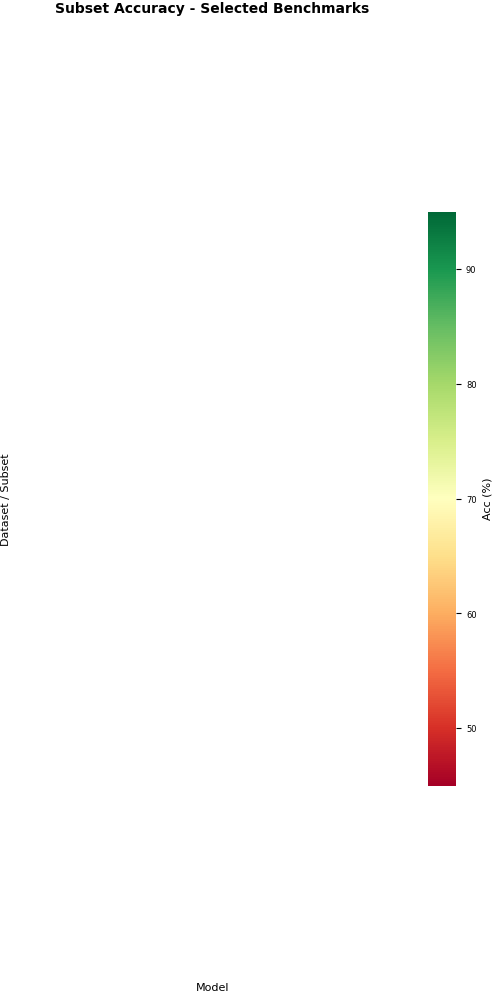

In [13]:
# =============================================================================
# COMPACT HEATMAP: Selected Datasets Only
# =============================================================================

def plot_compact_heatmap(table, datasets_to_show, models, figsize=(10, 6),
                          cmap="RdYlGn", save_path=None, use_short_names=True):
    """
    Plot a more compact heatmap showing only selected datasets.
    Rows = subsets, Columns = models
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    # Filter rows (subsets) to selected datasets
    rows = [r for r in table.index if r.split("/")[0] in datasets_to_show]
    models_exist = [m for m in models if m in table.columns]
    data = table.loc[rows, models_exist] * 100
    
    # Shortened model names
    model_labels = [m.replace(" (COCO)", "").replace(" (CC3M)", "") for m in models_exist]
    
    # Shorten row names
    if use_short_names:
        row_labels = []
        current_dataset = None
        for row in rows:
            dataset, subset = row.split("/")
            ds_short = get_dataset_display(dataset)
            sub_short = get_subset_display(subset)
            if dataset != current_dataset:
                row_labels.append(f"{ds_short}/{sub_short}")
                current_dataset = dataset
            else:
                row_labels.append(sub_short)
    else:
        row_labels = rows
    
    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    
    sns.heatmap(
        data,
        ax=ax,
        cmap=cmap,
        vmin=45,
        vmax=95,
        annot=True,
        fmt=".0f",
        annot_kws={"size": 6},
        cbar_kws={"label": "Acc (%)", "shrink": 0.6},
        linewidths=0.3,
        linecolor="white",
        xticklabels=model_labels,
        yticklabels=row_labels
    )
    
    ax.set_title("Subset Accuracy - Selected Benchmarks", fontsize=10, fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Dataset / Subset")
    
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=5)
    
    # Add horizontal lines between datasets
    for i, row in enumerate(rows[1:], 1):
        if row.split("/")[0] != rows[i-1].split("/")[0]:
            ax.axhline(y=i, color="black", linewidth=1.5)
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Plot compact heatmap
plot_compact_heatmap(
    subset_table,
    ["SugarCrepe", "VL_CheckList", "ARO"],
    SHOW_MODELS,
    figsize=(5, 10),
    save_path=FIGURES_DIR / "subset_heatmap_compact.pdf"
)

## Appendix Figures: Large Multi-Panel Plots

These are large, readable figures suitable for appendix with all datasets and subsets.

In [14]:
# =============================================================================
# APPENDIX FIGURE: Large Per-Dataset Subplot (One Page Per Dataset)
# =============================================================================

def plot_single_dataset_large(table, dataset_name, models, baseline_label="CLIP",
                               figsize=(8, 4), save_path=None, use_short_names=True):
    """
    Create a large, readable bar chart for a single dataset.
    Designed for appendix - larger fonts and more spacing.
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    # Get subsets for this dataset
    all_datasets = get_dataset_subsets(table)
    if dataset_name not in all_datasets:
        print(f"Dataset '{dataset_name}' not found")
        return None
    
    subsets = all_datasets[dataset_name]
    rows = [f"{dataset_name}/{s}" for s in subsets]
    models_exist = [m for m in models if m in table.columns]
    data = table.loc[rows, models_exist] * 100
    
    # Get display names
    if use_short_names:
        subset_labels = [get_subset_display(s) for s in subsets]
    else:
        subset_labels = subsets
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(subsets))
    n_models = len(models_exist)
    width = 0.75 / n_models
    
    for i, model in enumerate(models_exist):
        offset = (i - n_models/2 + 0.5) * width
        color = MODEL_STYLES.get(model, {}).get("color", COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)])
        
        # Highlight CS-CLIP
        edgecolor = "black" if model == "CS-CLIP" else "white"
        linewidth = 1.5 if model == "CS-CLIP" else 0.5
        hatch = "///" if model == "CS-CLIP" else None
        
        # Short display name for legend
        display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
        
        values = data[model].values
        ax.bar(x + offset, values, width, label=display_name, color=color,
               edgecolor=edgecolor, linewidth=linewidth, hatch=hatch, zorder=3)
        
        # Add value labels on bars
        for j, v in enumerate(values):
            ax.text(x[j] + offset, v + 0.5, f"{v:.0f}", ha="center", va="bottom", 
                   fontsize=5, rotation=90)
    
    # CLIP baseline line
    if baseline_label in models_exist:
        clip_avg = data[baseline_label].mean()
        ax.axhline(y=clip_avg, color="#777777", linestyle="--", linewidth=1.5, alpha=0.7,
                   label=f"CLIP avg ({clip_avg:.1f}%)")
    
    ax.set_xticks(x)
    ax.set_xticklabels(subset_labels, fontsize=9, rotation=30, ha="right")
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    
    # Use display name for title
    title_name = get_dataset_display(dataset_name)
    ax.set_title(f"{title_name}: Subset-Level Performance", fontsize=12, fontweight="bold")
    
    ax.legend(loc="upper right", fontsize=8, framealpha=0.95, ncol=2)
    
    # Dynamic y-limits
    min_val = data.min().min()
    max_val = data.max().max()
    ax.set_ylim(max(0, min_val - 10), min(100, max_val + 12))
    
    # Style
    ax.set_facecolor("white")
    ax.grid(True, axis="y", alpha=0.3, linestyle="-", linewidth=0.5, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Generate large individual plots for each dataset
all_datasets = list(get_dataset_subsets(subset_table).keys())
print(f"Generating large plots for {len(all_datasets)} datasets...")

for dataset in all_datasets:
    n_subsets = len(get_dataset_subsets(subset_table)[dataset])
    # Adjust figure width based on number of subsets
    fig_width = max(6, min(14, 2 + n_subsets * 0.8))
    
    plot_single_dataset_large(
        subset_table,
        dataset,
        SHOW_MODELS,
        figsize=(fig_width, 4),
        save_path=FIGURES_DIR / f"appendix_subset_{dataset.lower().replace('+', 'plus').replace(' ', '_')}.pdf"
    )

Generating large plots for 16 datasets...


KeyError: "None of [Index(['ARO/COCO_Order', 'ARO/Flickr30k_Order', 'ARO/VG_Attribution',\n       'ARO/VG_Relation'],\n      dtype='object', name='run_label')] are in the [index]"

In [ ]:
# =============================================================================
# APPENDIX FIGURE: All Datasets Grid (Large Readable Version)
# =============================================================================

def plot_all_datasets_appendix(table, models, datasets_to_show=None, ncols=3, 
                                subplot_height=2.8, subplot_width=4.5, save_path=None,
                                use_short_names=True):
    """
    Create a large multi-panel figure suitable for appendix.
    Each subplot is sized to be readable when printed.
    
    Parameters:
    -----------
    subplot_height: Height of each subplot in inches
    subplot_width: Width of each subplot in inches
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    all_datasets = get_dataset_subsets(table)
    if datasets_to_show is None:
        datasets_to_show = list(all_datasets.keys())
    
    # Filter to datasets that exist
    datasets_to_show = [d for d in datasets_to_show if d in all_datasets]
    
    if len(datasets_to_show) == 0:
        print("No datasets to show!")
        return None
    
    nrows = int(np.ceil(len(datasets_to_show) / ncols))
    figsize = (ncols * subplot_width, nrows * subplot_height)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)
    axes = axes.flatten()
    
    models_exist = [m for m in models if m in table.columns]
    
    for idx, (ax, dataset) in enumerate(zip(axes, datasets_to_show)):
        subsets = all_datasets[dataset]
        rows = [f"{dataset}/{s}" for s in subsets]
        data = table.loc[rows, models_exist] * 100
        
        # Get display names
        if use_short_names:
            subset_labels = [get_subset_display(s) for s in subsets]
        else:
            subset_labels = subsets
        
        x = np.arange(len(subsets))
        n_models = len(models_exist)
        width = 0.75 / n_models
        
        for i, model in enumerate(models_exist):
            offset = (i - n_models/2 + 0.5) * width
            color = MODEL_STYLES.get(model, {}).get("color", COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)])
            
            edgecolor = "black" if model == "CS-CLIP" else "white"
            linewidth = 1.0 if model == "CS-CLIP" else 0.3
            hatch = "///" if model == "CS-CLIP" else None
            
            # Short name for legend
            display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
            
            values = data[model].values
            ax.bar(x + offset, values, width, label=display_name if idx == 0 else "", 
                   color=color, edgecolor=edgecolor, linewidth=linewidth, hatch=hatch, zorder=3)
        
        ax.set_xticks(x)
        ax.set_xticklabels(subset_labels, fontsize=7, rotation=45, ha="right")
        
        # Use display name for title
        title_name = get_dataset_display(dataset)
        ax.set_title(title_name, fontsize=10, fontweight="bold", pad=5)
        
        # Dynamic y-limits per subplot
        min_val = data.min().min()
        max_val = data.max().max()
        ax.set_ylim(max(30, min_val - 8), min(100, max_val + 5))
        ax.tick_params(axis="y", labelsize=7)
        
        ax.set_facecolor("white")
        ax.grid(True, axis="y", alpha=0.3, linestyle="-", linewidth=0.3, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        # Y-label only on leftmost
        if idx % ncols == 0:
            ax.set_ylabel("Accuracy (%)", fontsize=8)
    
    # Hide unused axes
    for ax in axes[len(datasets_to_show):]:
        ax.set_visible(False)
    
    # Single legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(models_exist), fontsize=9,
               bbox_to_anchor=(0.5, -0.01), frameon=True, fancybox=True, shadow=False)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08, hspace=0.35, wspace=0.25)
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Generate full appendix figure with ALL datasets
all_datasets = list(get_dataset_subsets(subset_table).keys())
print(f"Creating appendix figure with {len(all_datasets)} datasets")
print(f"Datasets: {all_datasets}")

plot_all_datasets_appendix(
    subset_table,
    SHOW_MODELS,
    datasets_to_show=all_datasets,
    ncols=3,
    subplot_height=3.0,
    subplot_width=4.5,
    save_path=FIGURES_DIR / "appendix_all_subsets_grid.pdf"
)

In [ ]:
# =============================================================================
# APPENDIX FIGURE: Grouped by Capability Category
# =============================================================================

def get_datasets_by_capability(df, bench_cfg):
    """
    Group datasets by their primary capability category.
    Returns dict: {capability: [datasets]}
    """
    # Build lookup from benchmark config
    cap_to_datasets = {}
    
    for bench in bench_cfg.get("benchmarks", []):
        dataset = bench.get("dataset", "")
        caps = bench.get("capability_tags", [])
        
        for cap in caps:
            # Get top-level capability
            top_cap = cap.split("/")[0] if "/" in cap else cap
            
            if top_cap not in cap_to_datasets:
                cap_to_datasets[top_cap] = set()
            cap_to_datasets[top_cap].add(dataset)
    
    # Convert to lists
    return {k: sorted(list(v)) for k, v in cap_to_datasets.items()}


def plot_capability_group(table, models, capability_name, datasets_in_cap, 
                          ncols=2, subplot_height=3.0, subplot_width=5.0,
                          save_path=None, use_short_names=True):
    """
    Create a figure showing all datasets within a capability group.
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    all_datasets = get_dataset_subsets(table)
    
    # Filter to datasets that exist in this capability and have subsets
    datasets_to_show = [d for d in datasets_in_cap if d in all_datasets]
    
    if len(datasets_to_show) == 0:
        print(f"No datasets found for capability '{capability_name}'")
        return None
    
    nrows = int(np.ceil(len(datasets_to_show) / ncols))
    figsize = (ncols * subplot_width, nrows * subplot_height)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if nrows * ncols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    models_exist = [m for m in models if m in table.columns]
    
    for idx, (ax, dataset) in enumerate(zip(axes, datasets_to_show)):
        subsets = all_datasets[dataset]
        rows = [f"{dataset}/{s}" for s in subsets]
        data = table.loc[rows, models_exist] * 100
        
        # Get display names
        if use_short_names:
            subset_labels = [get_subset_display(s) for s in subsets]
        else:
            subset_labels = subsets
        
        x = np.arange(len(subsets))
        n_models = len(models_exist)
        width = 0.75 / n_models
        
        for i, model in enumerate(models_exist):
            offset = (i - n_models/2 + 0.5) * width
            color = MODEL_STYLES.get(model, {}).get("color", COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)])
            
            edgecolor = "black" if model == "CS-CLIP" else "white"
            linewidth = 1.0 if model == "CS-CLIP" else 0.3
            
            display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
            
            values = data[model].values
            ax.bar(x + offset, values, width, label=display_name if idx == 0 else "", 
                   color=color, edgecolor=edgecolor, linewidth=linewidth, zorder=3)
        
        ax.set_xticks(x)
        ax.set_xticklabels(subset_labels, fontsize=7, rotation=45, ha="right")
        
        title_name = get_dataset_display(dataset)
        ax.set_title(title_name, fontsize=10, fontweight="bold")
        
        min_val = data.min().min()
        max_val = data.max().max()
        ax.set_ylim(max(30, min_val - 8), min(100, max_val + 5))
        ax.tick_params(axis="y", labelsize=7)
        
        ax.set_facecolor("white")
        ax.grid(True, axis="y", alpha=0.3, linestyle="-", linewidth=0.3, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        if idx % ncols == 0:
            ax.set_ylabel("Accuracy (%)", fontsize=9)
    
    # Hide unused axes
    for ax in axes[len(datasets_to_show):]:
        ax.set_visible(False)
    
    # Title for capability group
    fig.suptitle(f"Capability: {capability_name}", fontsize=14, fontweight="bold", y=1.02)
    
    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(models_exist), fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1, top=0.95, hspace=0.35, wspace=0.25)
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Group datasets by capability
cap_to_datasets = get_datasets_by_capability(df, bench_cfg)
print("Datasets by capability:")
for cap, datasets_list in cap_to_datasets.items():
    print(f"  {cap}: {datasets_list}")

# Generate one figure per capability group
for capability, datasets_in_cap in cap_to_datasets.items():
    print(f"\n{'='*60}")
    print(f"Generating figure for: {capability}")
    print(f"{'='*60}")
    
    plot_capability_group(
        subset_table,
        SHOW_MODELS,
        capability,
        datasets_in_cap,
        ncols=2,
        subplot_height=3.0,
        subplot_width=5.5,
        save_path=FIGURES_DIR / f"appendix_capability_{capability.lower()}.pdf"
    )

In [ ]:
# =============================================================================
# APPENDIX FIGURE: Large Readable Heatmap with Shortened Names
# =============================================================================

def plot_appendix_heatmap(table, models, title="Subset-Level Accuracy", 
                           figsize=None, cmap="RdYlGn", vmin=45, vmax=95,
                           save_path=None, use_short_names=True,
                           is_delta=False, discrete=True,
                           delta_table=None):
    """
    Create a large, readable heatmap suitable for appendix.
    Uses shortened subset names for better readability.
    Models sorted by average improvement (descending).
    
    Parameters:
    -----------
    is_delta: If True, uses diverging colormap centered at 0 (Red=regression, Green=improvement)
    discrete: If True and is_delta, uses discrete color bins
    delta_table: If provided along with is_delta=False, colors by delta but shows accuracy values
    """
    plt.rcParams.update(fontsizes.icml2024())
    
    models_exist = [m for m in models if m in table.columns]
    
    # Sort columns by average delta (descending - best improvement first)
    if delta_table is not None:
        delta_cols = [m for m in models_exist if m in delta_table.columns]
        avg_delta = delta_table[delta_cols].mean(axis=0).sort_values(ascending=False)
        sorted_models = [m for m in avg_delta.index.tolist() if m in models_exist]
        # Add any models not in delta_table at the end
        sorted_models += [m for m in models_exist if m not in sorted_models]
        models_exist = sorted_models
    elif is_delta:
        # If this is a delta table, sort by average delta
        avg_delta = table[models_exist].mean(axis=0).sort_values(ascending=False)
        models_exist = avg_delta.index.tolist()
    
    data = table[models_exist] * 100
    
    # If we have delta_table, use it for coloring (reorder to match)
    if delta_table is not None and not is_delta:
        delta_for_color = delta_table[[m for m in models_exist if m in delta_table.columns]]
    else:
        delta_for_color = None
    
    # Shortened model names for display
    model_labels = [m.replace(" (COCO)", "").replace(" (CC3M)", "") for m in models_exist]
    
    # Shorten row labels (dataset/subset)
    if use_short_names:
        row_labels = []
        for idx in data.index:
            parts = idx.split("/")
            if len(parts) == 2:
                ds = get_dataset_display(parts[0])
                sub = get_subset_display(parts[1])
                row_labels.append(f"{ds}/{sub}")
            else:
                row_labels.append(idx)
    else:
        row_labels = list(data.index)
    
    # Auto figure size based on data dimensions
    if figsize is None:
        n_rows = len(data)
        n_cols = len(models_exist)
        figsize = (max(6, n_cols * 1.2), max(8, n_rows * 0.35))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap with appropriate colormap
    if delta_for_color is not None and discrete:
        # Show accuracy values but color by delta (discrete)
        cmap_obj = create_discrete_diverging_cmap(7)
        boundaries = [-15, -10, -5, -2, 2, 5, 10, 15]
        norm = BoundaryNorm(boundaries, cmap_obj.N, clip=True)
        
        # Plot heatmap colored by delta
        sns.heatmap(
            delta_for_color,
            ax=ax,
            cmap=cmap_obj,
            norm=norm,
            annot=False,
            cbar_kws={"label": "Δ vs CLIP (%)", "shrink": 0.7, "ticks": boundaries},
            linewidths=0.5,
            linecolor="white",
            xticklabels=model_labels,
            yticklabels=row_labels
        )
        
        # Add accuracy values as annotations (with 1 decimal place)
        for i in range(len(data.index)):
            for j in range(len(delta_for_color.columns)):
                col = delta_for_color.columns[j]
                if col in data.columns:
                    acc_val = data.loc[data.index[i], col]
                    delta_val = delta_for_color.iloc[i, j]
                    text_color = "white" if abs(delta_val) > 8 else "black"
                    ax.text(j + 0.5, i + 0.5, f"{acc_val:.1f}", 
                           ha="center", va="center", fontsize=6, color=text_color)
    elif is_delta and discrete:
        # Use discrete Red-Yellow-Green colormap
        cmap_obj = create_discrete_diverging_cmap(7)
        boundaries = [-15, -10, -5, -2, 2, 5, 10, 15]
        norm = BoundaryNorm(boundaries, cmap_obj.N, clip=True)
        
        sns.heatmap(
            data,
            ax=ax,
            cmap=cmap_obj,
            norm=norm,
            annot=True,
            fmt="+.0f",
            annot_kws={"size": 7},
            cbar_kws={"label": "Δ vs CLIP (%)", "shrink": 0.7, "ticks": boundaries},
            linewidths=0.5,
            linecolor="white",
            xticklabels=model_labels,
            yticklabels=row_labels
        )
    elif is_delta:
        # Continuous diverging for delta
        sns.heatmap(
            data,
            ax=ax,
            cmap="RdYlGn",
            center=0,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt="+.0f",
            annot_kws={"size": 7},
            cbar_kws={"label": "Δ vs CLIP (%)", "shrink": 0.7},
            linewidths=0.5,
            linecolor="white",
            xticklabels=model_labels,
            yticklabels=row_labels
        )
    else:
        # Absolute accuracy heatmap
        sns.heatmap(
            data,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt=".0f",
            annot_kws={"size": 7},
            cbar_kws={"label": "Accuracy (%)", "shrink": 0.7},
            linewidths=0.5,
            linecolor="white",
            xticklabels=model_labels,
            yticklabels=row_labels
        )
    
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("")  # Remove x-axis label
    ax.set_ylabel("Dataset / Subset", fontsize=10)
    
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(fontsize=7)
    
    # Add horizontal lines between datasets
    prev_dataset = None
    for i, idx in enumerate(data.index):
        current_dataset = idx.split("/")[0]
        if prev_dataset and current_dataset != prev_dataset:
            ax.axhline(y=i, color="black", linewidth=1.5)
        prev_dataset = current_dataset
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    return fig


# Generate large appendix heatmap - accuracy colored by delta
n_subsets = len(subset_table_filtered)
fig_height = max(10, n_subsets * 0.4)

# Main heatmap: accuracy values colored by delta
if len(delta_filtered) > 0:
    # Get aligned accuracy table
    acc_for_appendix = subset_table_filtered.loc[delta_filtered.index]
    
    plot_appendix_heatmap(
        acc_for_appendix,
        [m for m in SHOW_MODELS if m != BASELINE_LABEL],
        title="Compositional Benchmarks: Accuracy (colored by Δ vs CLIP)",
        figsize=(7, fig_height),
        delta_table=delta_filtered,  # Color by delta
        discrete=True,
        save_path=FIGURES_DIR / "appendix_heatmap_acc_delta_colored.pdf"
    )

# Also create pure delta heatmap for appendix
if len(delta_filtered) > 0:
    plot_appendix_heatmap(
        delta_filtered / 100,  # Convert back to 0-1 scale for the function
        [m for m in SHOW_MODELS if m != BASELINE_LABEL],
        title="Δ vs CLIP: All Subsets (percentage points)",
        is_delta=True,
        discrete=True,
        figsize=(7, fig_height),
        save_path=FIGURES_DIR / "appendix_heatmap_delta_all_subsets.pdf"
    )